In [24]:
import pandas as pd               
import seaborn as sns               
import matplotlib.pyplot as plt     
import numpy as np                  
import sweetviz as sv               

from rdkit import Chem             
from rdkit.Chem import Descriptors  
from rdkit.Chem import Crippen     
from rdkit.Chem import PandasTools  
PandasTools.RenderImagesInAllDataFrames(images=True) 

from sklearn.preprocessing import StandardScaler                            
from sklearn.model_selection import train_test_split                         
from sklearn.model_selection import cross_val_score, KFold                   
from sklearn.linear_model import LinearRegression                           
from sklearn.ensemble import RandomForestRegressor                          
from sklearn.dummy import DummyRegressor                                     
from sklearn.ensemble import RandomForestClassifier                          
from sklearn.metrics import mean_squared_error, r2_score                     
from sklearn.metrics import accuracy_score, precision_score, recall_score    
from sklearn.pipeline import make_pipeline                                  

[19:44:49] WARNING: not removing hydrogen atom without neighbors
[19:44:49] WARNING: not removing hydrogen atom without neighbors


,smiles,activity,HIV_active,mol
0,CCC1=[O+][Cu-3]2([O+]=C(CC)C1)[O+]=C(CC)CC(CC)...,CI,0,
1,C(=Cc1ccccc1)C1=[O+][Cu-3]2([O+]=C(C=Cc3ccccc3...,CI,0,
2,CC(=O)N1c2ccccc2Sc2c1ccc1ccccc21,CI,0,
3,Nc1ccc(C=Cc2ccc(N)cc2S(=O)(=O)O)c(S(=O)(=O)O)c1,CI,0,
4,O=S(=O)(O)CCS(=O)(=O)O,CI,0,

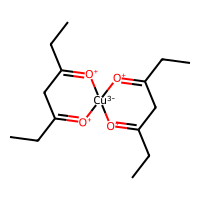
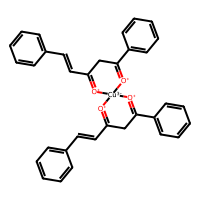
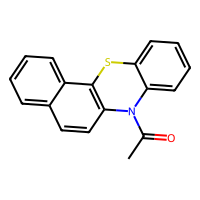
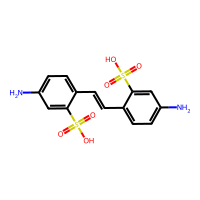
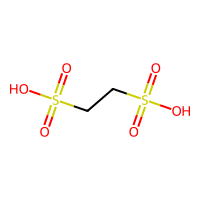

In [25]:
data_path = "HIV.csv"
df = pd.read_csv(data_path)
df['mol'] = df['smiles'].apply(Chem.MolFromSmiles)
df.head()

,smiles,activity,HIV_active,mol,MW,LogP,PolarSA,HDonor,HAcceptor,AromaticRings,FractionCSP3,RotBonds,MolRef,Bertz,BalabanJ
0,CCC1=[O+][Cu-3]2([O+]=C(CC)C1)[O+]=C(CC)CC(CC)...,CI,0,,319.888,2.6669,45.20,0,0,0,0.714286,4,70.4260,386.327861,2.470867
1,C(=Cc1ccccc1)C1=[O+][Cu-3]2([O+]=C(C=Cc3ccccc3...,CI,0,,564.140,7.0813,45.20,0,0,4,0.058824,6,151.7450,1493.142859,1.474572
2,CC(=O)N1c2ccccc2Sc2c1ccc1ccccc21,CI,0,,291.375,4.9890,20.31,0,2,3,0.055556,0,87.3330,871.976255,2.051191
3,Nc1ccc(C=Cc2ccc(N)cc2S(=O)(=O)O)c(S(=O)(=O)O)c1,CI,0,,370.408,1.5148,160.78,4,6,2,0.000000,4,90.2660,943.725350,2.586774
4,O=S(=O)(O)CCS(=O)(=O)O,CI,0,,190.198,-1.2380,108.74,2,4,0,1.000000,3,32.8312,249.709506,4.047792

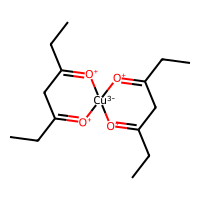
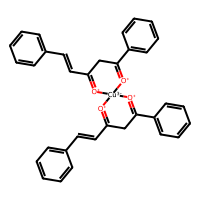
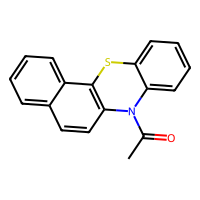
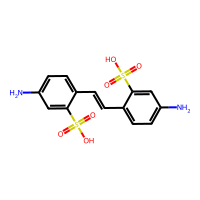
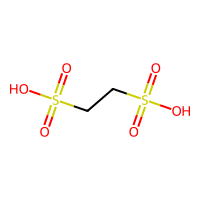

In [67]:
df = df.dropna(subset=['mol'])
df['MW'] = df['mol'].apply(Descriptors.MolWt)
df['LogP'] = df['mol'].apply(Descriptors.MolLogP) 
df['PolarSA'] = df['mol'].apply(Descriptors.TPSA)
df['AromaticRings'] = df['mol'].apply(Descriptors.NumAromaticRings)
df['FractionCSP3'] = df['mol'].apply(Descriptors.FractionCSP3)
df['RotBonds'] = df['mol'].apply(Descriptors.NumRotatableBonds)
df['MolRef'] = df['mol'].apply(Crippen.MolMR)
df['Bertz'] = df['mol'].apply(Descriptors.BertzCT)
df['BalabanJ'] = df['mol'].apply(Descriptors.BalabanJ)

df.head()

In [68]:
df_nomol = df.drop(columns = ['mol'])
report = sv.analyze(df_nomol)

                                             |          | [  0%]   00:00 -> (? left)

In [69]:
X = df.drop(columns=['HIV_active'])

x = X["LogP"]
y = df['HIV_active']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=123, shuffle=True)

x_train = x_train.values.reshape(-1,1)
x_test = x_test.values.reshape(-1,1)
y_train = y_train.values.reshape(-1,1)
y_test = y_test.values.reshape(-1,1)

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((32901, 1), (8226, 1), (32901, 1), (8226, 1))

In [70]:

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print(f" Training feature mean: {x_train_scaled.mean():.5f}")
print(f" Training feature standard deviation: {x_train_scaled.std():.5f}\n")

print(f" Testing feature mean: {x_test_scaled.mean():.5f}")
print(f" Testing feature standard deviation: {x_test_scaled.std():.5f}")

 Training feature mean: -0.00000
 Training feature standard deviation: 1.00000

 Testing feature mean: 0.00803
 Testing feature standard deviation: 0.97020


In [71]:
dummy_model = DummyRegressor(strategy="mean")
dummy_model.fit(x_train_scaled, y_train)
y_pred_dummy = dummy_model.predict(x_test_scaled)

results = pd.DataFrame({
    "Coefficients": [np.array(dummy_model.constant_)],   
    "MSE": mean_squared_error(y_test, y_pred_dummy),     
    "R2": r2_score(y_test, y_pred_dummy)                 
}, index=["Dummy"])
                            
results.style.format(
    {
        "MSE": "{:.3f}",
        "R2": "{:.2f}"
    })


,Coefficients,MSE,R2
Dummy,[[0.03565241]],0.032,-0.00


In [72]:
simple_reg_model = LinearRegression()
simple_reg_model.fit(x_train_scaled, y_train)
y_pred_simple = simple_reg_model.predict(x_test_scaled)
simple_model_results = pd.DataFrame({
    "Coefficients": [np.array(simple_reg_model.coef_)],  
    "MSE": mean_squared_error(y_test, y_pred_simple),     
    "R2": r2_score(y_test, y_pred_simple)               
}, index=["Simple-Linear-Regression"])

results = pd.concat([results, simple_model_results])
results

,Coefficients,MSE,R2
Dummy,[[0.035652411780796936]],0.031753,-0.000252
Simple-Linear-Regression,[[0.01009449838615269]],0.031586,0.005007


In [73]:
X = df[['MW', 'LogP', 'PolarSA', 'AromaticRings', 'FractionCSP3', 'RotBonds', 'MolRef', 'Bertz', 'BalabanJ']]
y = df['HIV_active']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123, shuffle=True)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((32901, 9), (8226, 9), (32901,), (8226,))

In [74]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf_model = RandomForestClassifier(random_state=123, class_weight='balanced')
lr_model = LogisticRegression(max_iter=1000)

rf_model.fit(X_train_scaled, y_train)
lr_model.fit(X_train_scaled, y_train)

rf_pred = rf_model.predict(X_test_scaled)
lr_pred = lr_model.predict(X_test_scaled)


In [75]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
lr_model = LogisticRegression(max_iter=1000)

rf_model.fit(X_train_scaled, y_train)
lr_model.fit(X_train_scaled, y_train)

rf_pred = rf_model.predict(X_test_scaled)
lr_pred = lr_model.predict(X_test_scaled)

/opt/conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


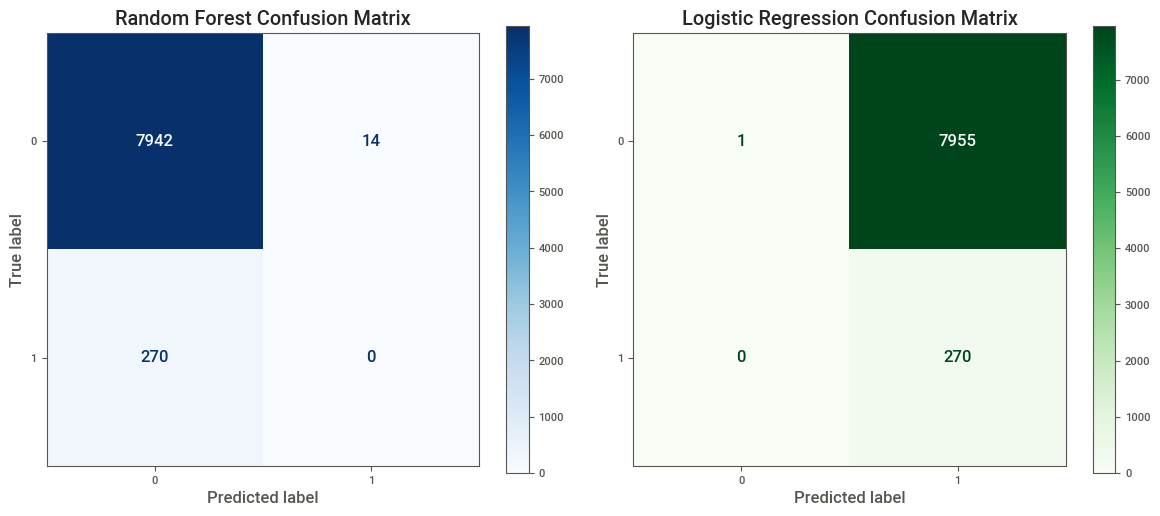

In [76]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test, ax=ax[0], cmap='Blues')
ax[0].set_title('Random Forest Confusion Matrix')
ConfusionMatrixDisplay.from_estimator(lr_model, X_test, y_test, ax=ax[1], cmap='Greens')
ax[1].set_title('Logistic Regression Confusion Matrix')

plt.tight_layout()
plt.show()

In [77]:
X_clf = df[['MW', 'LogP', 'PolarSA', 'AromaticRings', 'FractionCSP3', 'RotBonds', 'MolRef', 'Bertz', 'BalabanJ']]
y_clf = df['HIV_active']

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(X_clf, y_clf, test_size=0.2, random_state=123, shuffle=True)

X_clf_train.shape, X_clf_test.shape, y_clf_train.shape, y_clf_test.shape

((32901, 9), (8226, 9), (32901,), (8226,))

In [78]:
scaler = StandardScaler()

X_clf_train_scaled = scaler.fit_transform(X_clf_train)
X_clf_test_scaled = scaler.transform(X_clf_test)

print(f" Training feature mean: {X_clf_train_scaled.mean():.5f}")
print(f" Training feature standard deviation: {X_clf_train_scaled.std():.5f}\n")

print(f" Testing feature mean: {X_clf_test_scaled.mean():.5f}")
print(f" Testing feature standard deviation: {X_clf_test_scaled.std():.5f}")

 Training feature mean: 0.00000
 Training feature standard deviation: 1.00000

 Testing feature mean: -0.00336
 Testing feature standard deviation: 0.99442


In [79]:
default_rf_clf_model = RandomForestClassifier()
default_rf_clf_model.fit(X_clf_train_scaled, y_clf_train)
y_pred_default_rf_clf = default_rf_clf_model.predict(X_clf_test_scaled)

default_rf_clf_model_results = pd.DataFrame({
    "Accuracy": accuracy_score(y_clf_test, y_pred_default_rf_clf),     # the accuracy score
    "Precision": precision_score(y_clf_test, y_pred_default_rf_clf),   # the precision score
    "Recall": recall_score(y_clf_test, y_pred_default_rf_clf)          # the recall score
}, index=["Default_RF_Classifier"])

default_rf_clf_model_results

,Accuracy,Precision,Recall
Default_RF_Classifier,0.970095,0.681818,0.166667


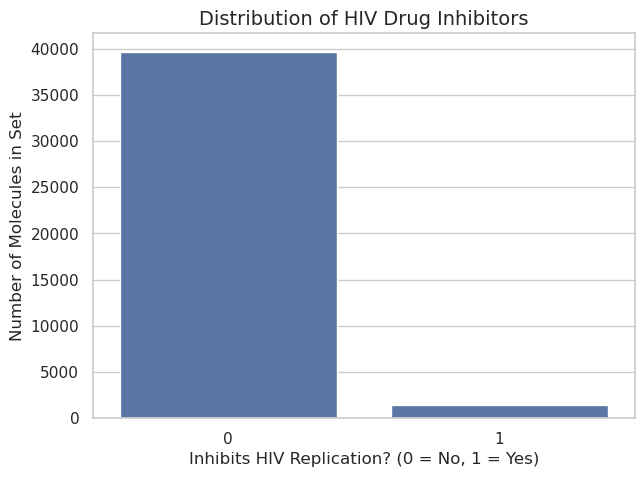

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the visual style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(7, 5))
sns.countplot(x='HIV_active', data=df) 

plt.title('Distribution of HIV Drug Inhibitors', fontsize=14)
plt.xlabel('Inhibits HIV Replication? (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Number of Molecules in Set', fontsize=12)

plt.savefig('target_distribution.png', dpi=300)
plt.show()

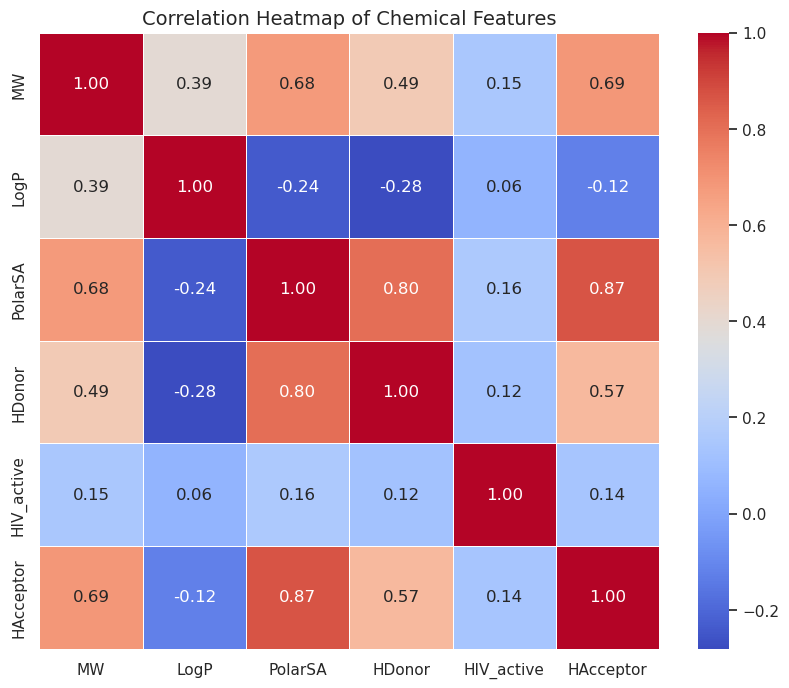

In [81]:
columns_to_plot = ['MW', 'LogP', 'PolarSA', 'HDonor', 'HIV_active', 'HAcceptor']
corr_matrix = df[columns_to_plot].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Chemical Features', fontsize=14)
plt.savefig('correlation_heatmap.png', dpi=300)
plt.show()